In [13]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

In [14]:
import pandas as pd

data_path = 'Diseases_and_Symptoms_dataset.csv'

df = pd.read_csv(data_path)

disease_col = "diseases"
symptom_cols = [c for c in df.columns if c != disease_col]

print("Dataset Shape:", df.shape)
print("Number of Diseases:", df[disease_col].nunique())
print("Number of Symptoms:", len(symptom_cols))

Dataset Shape: (96088, 231)
Number of Diseases: 100
Number of Symptoms: 230


In [15]:
le = LabelEncoder()
y = le.fit_transform(df[disease_col])

In [16]:
X = df[symptom_cols]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (76870, 230)
Test size: (19218, 230)


In [17]:
print("Columns in df:", df.shape[1])
print("symptom_cols length:", len(symptom_cols))
print("X shape:", X.shape)

Columns in df: 231
symptom_cols length: 230
X shape: (96088, 230)


In [18]:
column_names = np.array(df.columns)
for c in column_names:
    print(c, "\", \"", end="")
print(f"Total columns: {len(column_names)}")

diseases ", "anxiety and nervousness ", "depression ", "shortness of breath ", "depressive or psychotic symptoms ", "sharp chest pain ", "dizziness ", "insomnia ", "abnormal involuntary movements ", "chest tightness ", "palpitations ", "irregular heartbeat ", "breathing fast ", "hoarse voice ", "sore throat ", "difficulty speaking ", "cough ", "nasal congestion ", "throat swelling ", "diminished hearing ", "difficulty in swallowing ", "skin swelling ", "retention of urine ", "leg pain ", "hip pain ", "suprapubic pain ", "blood in stool ", "lack of growth ", "symptoms of the scrotum and testes ", "swelling of scrotum ", "pain in testicles ", "pus draining from ear ", "jaundice ", "white discharge from eye ", "irritable infant ", "abusing alcohol ", "fainting ", "hostile behavior ", "drug abuse ", "sharp abdominal pain ", "feeling ill ", "vomiting ", "headache ", "nausea ", "diarrhea ", "vaginal itching ", "painful urination ", "involuntary urination ", "pain during intercourse ", "frequ

In [19]:
results = {}

#RandomForest
model_rf = RandomForestClassifier(
    n_estimators=400,
    class_weight="balanced",
    random_state=42
)

model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
results["RandomForest"] = acc_rf
print("\n=== Random Forest ===")
print("Accuracy:", acc_rf)
print(classification_report(y_test, pred_rf, target_names=le.classes_))


=== Random Forest ===
Accuracy: 0.8710583827661568
                                              precision    recall  f1-score   support

                           actinic keratosis       0.75      0.73      0.74       162
                         acute bronchiolitis       0.93      0.89      0.91       241
                            acute bronchitis       0.76      0.73      0.75       243
                          acute bronchospasm       0.54      0.63      0.58       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.91      0.85      0.88       241
                             acute sinusitis       0.86      0.87      0.87       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.93      0.97      0.95       165
                                     anxiety       0.95      0.97      0.96       240
 

In [20]:
#XGBoost
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.9,
    objective='multi:softmax',
    num_class=len(le.classes_),
    eval_metric='mlogloss'
)

model_xgb.fit(X_train, y_train)
pred_xgb = model_xgb.predict(X_test)
acc_xgb = accuracy_score(y_test, pred_xgb)
results["XGBoost"] = acc_xgb
print("\n=== XGBoost ===")
print("Accuracy:", acc_xgb)
print(classification_report(y_test, pred_xgb, target_names=le.classes_))


=== XGBoost ===
Accuracy: 0.8688729316266001
                                              precision    recall  f1-score   support

                           actinic keratosis       0.74      0.73      0.74       162
                         acute bronchiolitis       0.90      0.89      0.90       241
                            acute bronchitis       0.75      0.74      0.74       243
                          acute bronchospasm       0.57      0.60      0.59       162
                         acute kidney injury       0.96      0.98      0.97       162
                          acute pancreatitis       0.91      0.85      0.88       241
                             acute sinusitis       0.86      0.86      0.86       166
                                     allergy       0.95      0.98      0.96       161
                                      angina       0.93      0.97      0.95       165
                                     anxiety       0.95      0.96      0.95       240
       

In [21]:
model_lr = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial"
)

model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
results["Logistic Regression"] = acc_lr
print("\n=== Logistic Regression ===")
print("Accuracy:", acc_lr)
print(classification_report(y_test, pred_lr, target_names=le.classes_))


=== Logistic Regression ===
Accuracy: 0.8985326256634405
                                              precision    recall  f1-score   support

                           actinic keratosis       0.93      0.72      0.81       162
                         acute bronchiolitis       0.95      0.92      0.93       241
                            acute bronchitis       0.87      0.76      0.81       243
                          acute bronchospasm       0.66      0.78      0.71       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.93      0.85      0.89       241
                             acute sinusitis       0.85      0.92      0.88       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.95      0.98      0.96       165
                                     anxiety       0.97      0.97      0.97      

In [22]:

results["Logistic Regression"] = acc_lr
print("\n=== Logistic Regression ===")
print("Accuracy:", acc_lr)
print(classification_report(y_test, pred_lr, target_names=le.classes_))


=== Logistic Regression ===
Accuracy: 0.8985326256634405
                                              precision    recall  f1-score   support

                           actinic keratosis       0.93      0.72      0.81       162
                         acute bronchiolitis       0.95      0.92      0.93       241
                            acute bronchitis       0.87      0.76      0.81       243
                          acute bronchospasm       0.66      0.78      0.71       162
                         acute kidney injury       0.98      0.99      0.98       162
                          acute pancreatitis       0.93      0.85      0.89       241
                             acute sinusitis       0.85      0.92      0.88       166
                                     allergy       0.94      0.98      0.96       161
                                      angina       0.95      0.98      0.96       165
                                     anxiety       0.97      0.97      0.97      

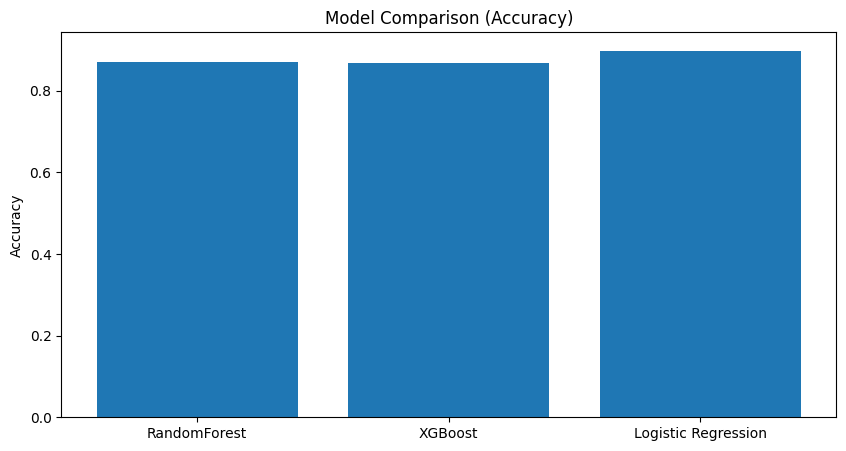


🔍 Best model: Logistic Regression


In [23]:
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())
plt.title("Model Comparison (Accuracy)")
plt.ylabel("Accuracy")
plt.show()

print("\n🔍 Best model:", max(results, key=results.get))


In [ ]:
# # IMPORTANT: Save the trained model to model.pkl

# MODEL_FILENAME = 'model/model.pkl'

# try:
#     joblib.dump(model_lr, MODEL_FILENAME)
#     print(f"\n✅ Model successfully saved to {MODEL_FILENAME}")

#     # You MUST also save the LabelEncoder to decode predictions in main.py if not using joblib's classes_ attribute
#     # However, LogisticRegression stores the class names in the model.classes_ attribute,
#     # which joblib will save automatically.
    
# except Exception as e:
#     print(f"\n❌ ERROR: Could not save model using joblib: {e}")